<a href="https://colab.research.google.com/github/mandar-solanki/exercises/blob/main/2604-Applied-Data-Modelling-using-Gradio/0429%20EDA%20on%20Appraisal%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Topics Covered Today
1) 3 EDA on Hire Data
2) Appraisal Analysis Gradio App - Capstone Project



##### 1) EDA on Hire Data


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr


In [2]:
data = pd.read_csv(r'https://raw.githubusercontent.com/suyashi29/python-su/refs/heads/master/Applied%20Data%20Modelling%20using%20Gradio/hiredata.csv')


In [3]:
data.head()


,YearsExperience,EducationLevel,SkillsScore,CertificationCount,Hired
0,6,High School,88,0,0
1,3,High School,50,3,0
2,12,PhD,78,2,1
3,14,Post-Graduate,63,3,1
4,10,High School,99,3,1


In [4]:
data.shape


(1200, 5)

In [5]:
data.isnull().sum()


,0
YearsExperience,0
EducationLevel,0
SkillsScore,0
CertificationCount,0
Hired,0


In [6]:
data.describe(include='all')


,YearsExperience,EducationLevel,SkillsScore,CertificationCount,Hired
count,1200.000000,1200,1200.000000,1200.000000,1200.000000
unique,NaN,5,NaN,NaN,NaN
top,NaN,PhD,NaN,NaN,NaN
freq,NaN,247,NaN,NaN,NaN
mean,6.952500,NaN,69.496667,3.456667,0.412500
std,4.378686,NaN,17.345192,2.267688,0.492489
min,0.000000,NaN,40.000000,0.000000,0.000000
25%,3.000000,NaN,55.000000,2.000000,0.000000
50%,7.000000,NaN,69.000000,3.000000,0.000000
75%,11.000000,NaN,84.000000,5.000000,1.000000


### 2) Appraisal Analysis EDA

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr


In [8]:
df = pd.read_csv(r'https://raw.githubusercontent.com/suyashi29/python-su/refs/heads/master/Applied%20Data%20Modelling%20using%20Gradio/appraisal_dataset.csv')


In [9]:
df.head()


,Rating,Behavior,Experience,Band,Band_Num,Appraisal
0,3.1,4.9,9,B4,3,84.85
1,4.9,4.8,7,B2,1,93.65
2,4.2,3.4,17,B2,1,94.82
3,3.8,4.6,17,B2,1,86.69
4,2.5,4.5,2,B2,1,63.45


In [11]:
# Load Data
def load_data():
    return pd.read_csv(r'https://raw.githubusercontent.com/suyashi29/python-su/refs/heads/master/Applied%20Data%20Modelling%20using%20Gradio/appraisal_dataset.csv')

def get_y():
    df = load_data()
    return df.columns[-1]

def get_x():
    df = load_data()
    return df.columns[:-1]


In [26]:
str(get_y())


'Appraisal'

In [18]:
get_x().to_list()


['Rating', 'Behavior', 'Experience', 'Band', 'Band_Num']

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

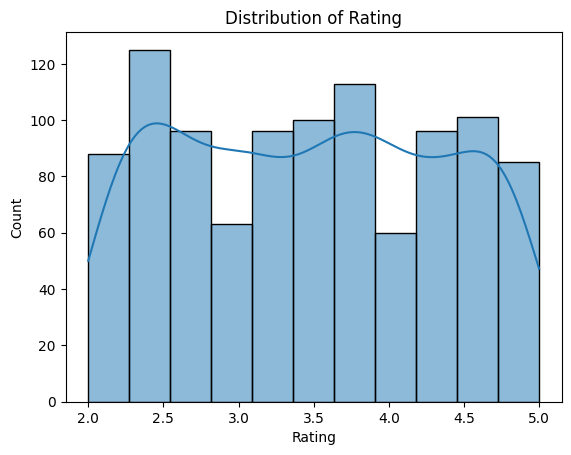

In [12]:
# Univariate Analysis
def plot_univariate(column):
    df = load_data()
    plt.figure()
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    return plt

plot_univariate('Rating')


/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cset = contour_func(


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

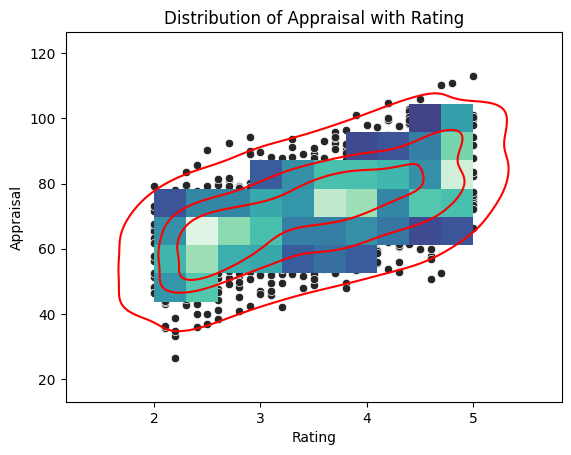

In [13]:
# Bivariate Analysis
def plot_bivariate(column):
    df = load_data()
    y_col = get_y()
    plt.figure()
    sns.scatterplot(x=df[column], y=df[y_col], color='.15')
    sns.histplot(x=df[column], y=df[y_col], bins=10, pthresh=.1, cmap='mako')
    sns.kdeplot(x=df[column], y=df[y_col], levels=4, color='r', linewidth=1)
    plt.title(f'Distribution of {y_col} with {column}')
    return plt

plot_bivariate('Rating')


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

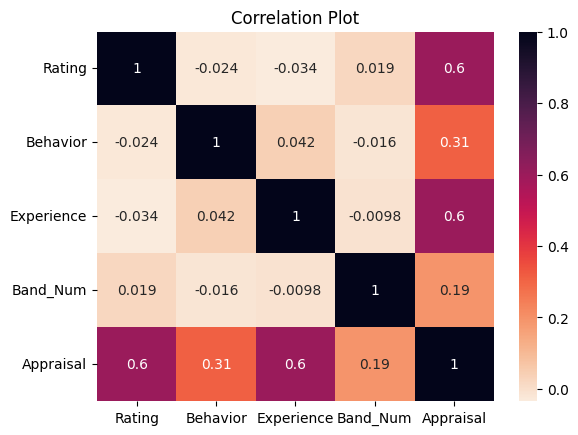

In [14]:
# Correlation Plot
def correlation_plot():
    df = load_data()
    plt.figure()
    sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='rocket_r')
    plt.title('Correlation Plot')
    return plt

correlation_plot()


In [27]:
with gr.Blocks() as app:
    with gr.Column():
        gr.Markdown('# Appraisal Analysis')
        with gr.Row():
            with gr.Column():
                gr.Markdown('### Univariate Analysis')
                uni_plot = gr.Plot()
            with gr.Column():
                gr.Markdown('### Bivariate Analysis')
                bi_plot = gr.Plot()
            with gr.Column():
                gr.Markdown('### Correlation Heatmap')
                corr_plot = gr.Plot()
        with gr.Row():
            with gr.Column():
                uni_col = gr.Dropdown(get_x().to_list())
                gr.Button('Plot Histogram').click(fn=plot_univariate, inputs=uni_col, outputs=uni_plot)
            with gr.Column():
                bi_col = gr.Dropdown(get_x().to_list())
                gr.Button(f'Compare with {get_y()}').click(fn=plot_bivariate, inputs=bi_col, outputs=bi_plot)
            with gr.Column():
                gr.Button('Show Correlation').click(fn=correlation_plot, outputs=corr_plot)



In [32]:
app.launch(share=False, debug=True)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

Keyboard interruption in main thread... closing server.


In [33]:
app.close()

Closing server running on port: 7860
